# Task 1: Linear Regression (House Prices)
# Exploratory Data Analysis(EDA)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('train.csv')

In [12]:
# Basic shape and types
print(df.shape)
print(df.dtypes)
print(df.describe())

(1460, 81)
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

   

In [13]:
# Check missing values
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


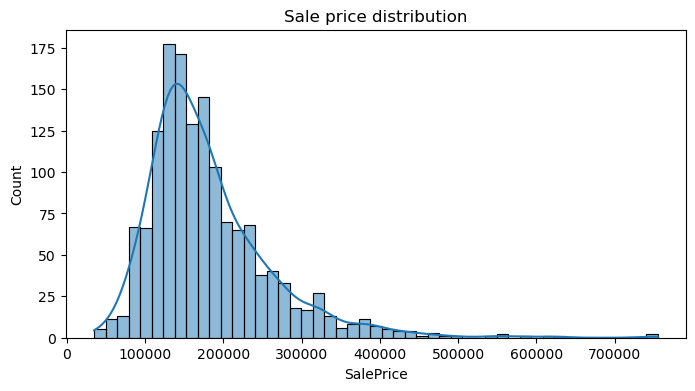

In [14]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Sale price distribution')
plt.savefig('price_distribution.png')
plt.show()

In [15]:
# Correlation heatmap — top 10 features
top_corr = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)[:10]
print(top_corr)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


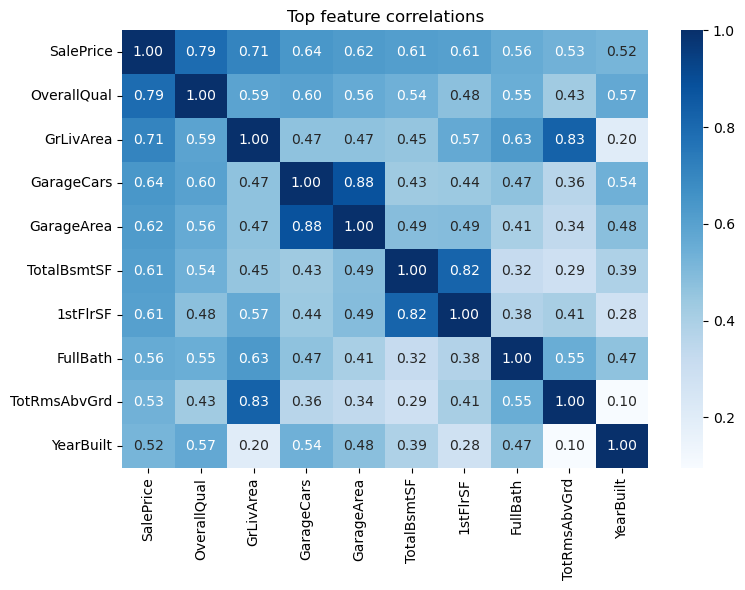

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[top_corr.index].corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Top feature correlations')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

Ths EDA will show that OverallQual, GrLivArea, GarageCars, TotalBsmtSF, and FullBath are the strongest predictos of SalesPrice

# Preprocessing

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [23]:
# Select the most relevant numeric features
features = ['OverallQual', 'GrLivArea', 'GarageCars',
            'TotalBsmtSF', 'FullBath', 'YearBuilt',
            'YearRemodAdd', 'Fireplaces', 'BedroomAbvGr']

target = 'SalePrice'

In [24]:
# Drop rows where target or any feature is null
model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

In [25]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Scale features: to prevent data lekage scaler.fit_transform() is used on training set and 
# scaler.transform() is used on test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 1168
Test samples:     292


# Train the model

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [28]:
# Inspect coefficients
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coeff_df)
print(f"\nIntercept: {model.intercept_:,.0f}")

        Feature   Coefficient
1     GrLivArea  27406.520939
0   OverallQual  24096.901844
2    GarageCars  10704.332427
3   TotalBsmtSF  10029.080524
5     YearBuilt   8219.936716
6  YearRemodAdd   6619.371281
7    Fireplaces   6380.752500
4      FullBath  -2341.348362
8  BedroomAbvGr  -3868.788125

Intercept: 181,442


# Evaluate and Visualize

In [33]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"RMSE:  ${rmse:,.0f}")
print(f"R²:    {r2:.4f}")

RMSE:  $38,905
R²:    0.8027


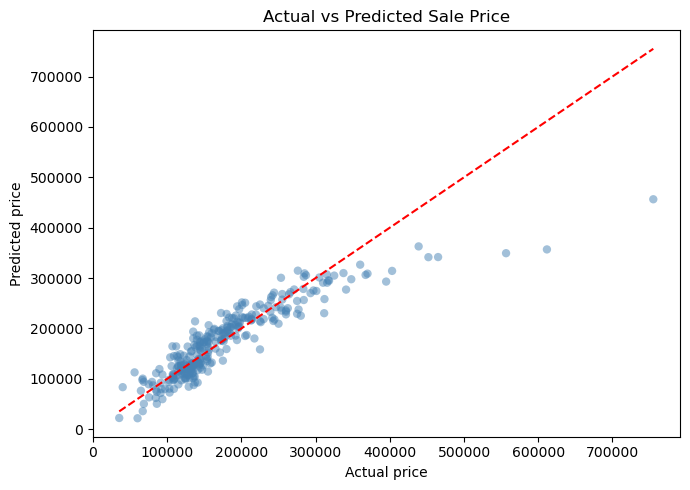

In [34]:
# Actual vs predicted scatter
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted Sale Price')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

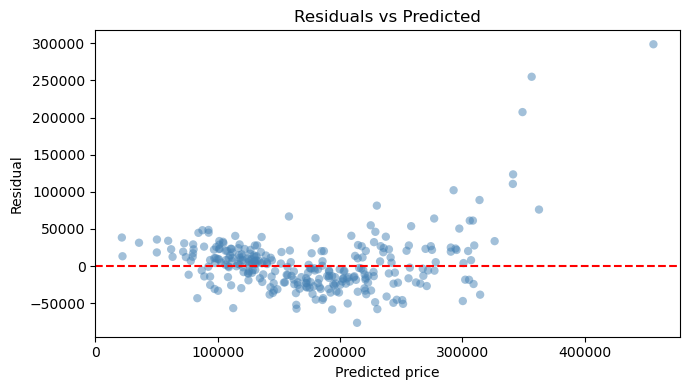

In [35]:
# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.5, color='steelblue', edgecolors='none')
plt.axhline(0, color='red', linestyle='--', lw=1.5)
plt.xlabel('Predicted price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.savefig('residuals_plot.png')
plt.show()